In [1]:
#create env
import os
print(os.getcwd())          
print(os.listdir('.')) 

/Users/apple/Desktop/dataset_1
['.DS_Store', 'Nat_gas_estimation.ipynb', 'venv']


In [2]:
#import dataset
import pandas as pd
df = pd.read_csv("/Users/apple/Downloads/Nat_Gas.csv")
df.head(49)


,Dates,Prices
0,10/31/20,10.10
1,11/30/20,10.30
2,12/31/20,11.00
3,1/31/21,10.90
4,2/28/21,10.90
5,3/31/21,10.90
6,4/30/21,10.40
7,5/31/21,9.84
8,6/30/21,10.00
9,7/31/21,10.10


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     str    
 1   Prices  48 non-null     float64
dtypes: float64(1), str(1)
memory usage: 900.0 bytes


In [4]:
#Data parsing the datetime format and the price index
df = pd.read_csv("/Users/apple/Downloads/Nat_Gas.csv")
df['Dates']= pd.to_datetime(df['Dates'], format='%m/%d/%y')
df = df.set_index('Dates').sort_index()
assert df['Prices'].isna().sum()==0

In [5]:
#engineer the datetime index
origin = df.index[0]
df['t'] = ((df.index.year - origin.year) * 12 + (df.index.month - origin.month))

In [6]:
#Detect and handle outliers
import numpy as np
from scipy import stats
z = np.abs(stats.zscore(df['Prices']))
outliers = df[z>2.5]
print(outliers)

Empty DataFrame
Columns: [Prices, t]
Index: []


In [8]:
#Polynomial Regression
#imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

origin = df.index[0]
df['t'] = ((df.index.year - origin.year) * 12
           + (df.index.month - origin.month))

#train/test split
train = df[df['t'] <= 35]
test = df[df['t'] >= 36]
x_train = train[['t']].values
y_train = train['Prices'].values
x_test = test[['t']].values
y_test = test['Prices'].values

#fit pipeline with degree 2 as the most optimal estimation 
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=True)),
    ('model', LinearRegression())
])
poly_pipeline.fit(x_train, y_train)

#evaluation
y_pred_test = poly_pipeline.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2   = r2_score(y_test, y_pred_test)
print(f"Polynomial Regression — RMSE: {rmse:.4f}  R²: {r2:.4f}")

#refit to poly_final data
poly_final = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=True)),
    ('model', LinearRegression())
])
poly_final.fit(df[['t']].values, df['Prices'].values)

#forecast for 12 months
future_t     = np.arange(48, 60).reshape(-1, 1)
future_dates = pd.date_range('2024-10-31', periods=12, freq='ME')
poly_forecast = poly_final.predict(future_t)

#confidence interval
residuals = df['Prices'].values - poly_final.predict(df[['t']].values)
sigma = np.std(residuals)
margins = 1.96 * sigma * np.array([1 + 0.05 * max(0, t - 47) for t in range(48, 60)])
poly_ci_lo = poly_forecast - margins
poly_ci_hi = poly_forecast + margins

#estimate function
def poly_estimate(date_str):
    date = pd.to_datetime(date_str)
    t = (date.year - origin.year) * 12 + (date.month - origin.month)
    price = poly_final.predict([[t]])[0]
    margin = 1.96 * sigma * (1 + 0.05 * max(0, t - 47))
    return {
        'date': date_str,
        'estimate': round(price, 4),
        'ci_lower': round(price - margin, 4),
        'ci_upper': round(price + margin, 4)
    }
print(poly_estimate('2025-03-31'))

#the result shows that R^2 of degree 2 give -0.6539 which is a fair estimatiion of the given dataset


Polynomial Regression — RMSE: 0.6197  R²: -0.6539
{'date': '2025-03-31', 'estimate': np.float64(12.3004), 'ci_lower': np.float64(10.9761), 'ci_upper': np.float64(13.6247)}


In [9]:
#loading data
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for degree in [2]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=True)),
        ('model', LinearRegression())
    ])
    scores = cross_val_score(pipe, df[['t']].values, df['Prices'].values,
                             cv=tscv, scoring='r2')
    print(f"Degree {degree} — CV R² scores: {scores.round(3)}  |  Mean: {scores.mean():.4f}")



Degree 2 — CV R² scores: [-127.193  -19.007   -6.923    0.229   -3.886]  |  Mean: -31.3560


In [10]:
#exposing estimator using FastApi
from fastapi import FastAPI
app = FastAPI()

@app.get("/estimate")
def estimate(date: str):
    t - date_to_t(date)
    price = pipeline.predict([[t]])[0]
    lo, hi = confidence_interval(t)
    return {"date": date, "price":round(price,4),
            "ci_lower": round(lo,4),"ci_upper": round(hi,4)}


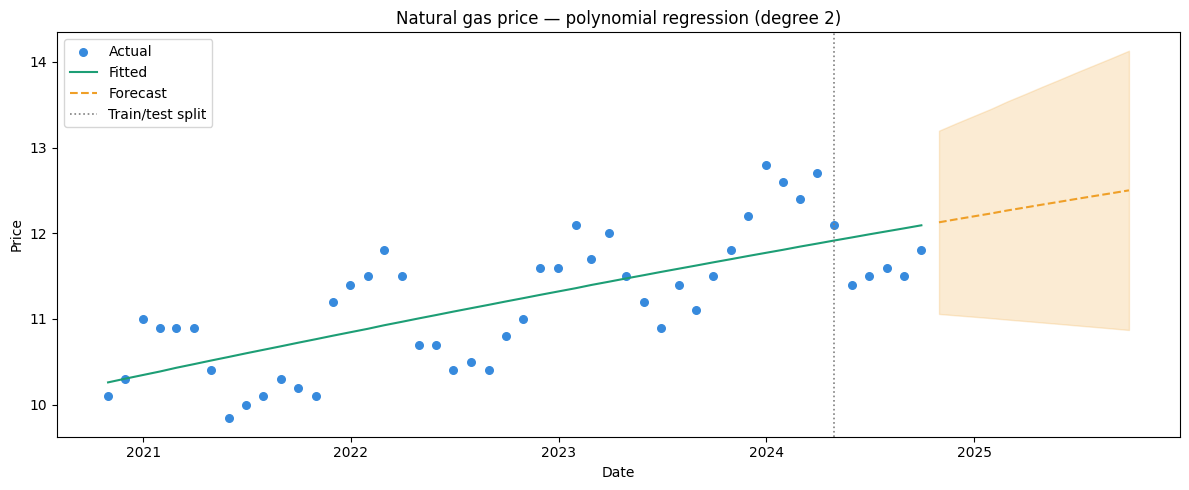

In [13]:
#Visualisation of actual vs fitted vs forecat

fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(df.index, df['Prices'], label='Actual', s=30, color='#378ADD')
ax.plot(df.index, poly_final.predict(df[['t']].values), label='Fitted', color='#1D9E75')
ax.plot(future_dates, poly_forecast, '--', label='Forecast', color='#EF9F27')
ax.fill_between(future_dates, poly_ci_lo, poly_ci_hi, alpha=0.2, color='#EF9F27')
ax.axvline(pd.Timestamp('2024-04-30'), color='gray', linestyle=':', lw=1.2, label='Train/test split')

ax.set_title('Natural gas price — polynomial regression (degree 2)')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

#using scatter, plot and fill_between in the graph the model visualises the actual data in scatter
#the poly_final model fitted in the the dataset forms a plot graph showing the predicted values
#the forecast shows the future dates estimation for high and low of forecast

